## Ex:2 Data Wrangling and Transformation 
### Objective

To perform data wrangling and transformation on a dataset using Python and Pandas by handling missing values, removing duplicates, correcting data types, filtering data, and transforming variables into a suitable format for data analysis and machine learning.



##  Dataset Description

The dataset contains information about **student academic performance, educational background, MBA specialization, and placement salary**.

###  Dataset Attributes

| Column | Description |
|:---|:---|
| `sl_no` | Serial number / student identifier |
| `gender` | Gender of the student |
| `hsc_p` | Higher Secondary / 12th percentage |
| `hsc_s` | Higher Secondary stream |
| `degree_p` | Undergraduate degree percentage |
| `degree_t` | Undergraduate degree type |
| `etest_p` | Employability / entrance test percentage |
| `specialisation` | MBA specialization |
| `mba_p` | MBA percentage |
| `salary` | Salary offered after placement |

---

## Experiment Question

 **Using the given student placement dataset, perform data wrangling and transformation by handling missing values, scaling numerical features, detecting and treating outliers, encoding categorical variables, and generating a final model-ready dataset.**




Data wrangling and transformation is the process of converting raw student placement data into a clean, consistent, and machine-learning-ready dataset. In this experiment, the given student placement dataset is first loaded into a Pandas DataFrame and explored by examining its rows, columns, data types, and descriptive statistics. Missing values are then identified and handled by removing records with missing `salary` values and replacing missing values in `hsc_p`, `degree_p`, and `etest_p` with their respective mean values. The numerical attributes such as `hsc_p`, `degree_p`, `etest_p`, and `salary` are transformed using feature-scaling techniques such as `StandardScaler` and `MinMaxScaler` to bring the variables into suitable numerical ranges. The dataset is then divided into input features (`X`) and the target variable (`Y`), where `salary` is considered the target. The preprocessed data is saved as `Pre.csv` for further processing. Next, possible outliers in the `salary` attribute are identified using a boxplot and statistically detected using the Z-score method, where values with an absolute Z-score greater than 3 are considered potential outliers. Outliers are also treated using the capping and flooring method by calculating the 5th and 95th percentiles and replacing values outside these limits with the corresponding boundary values. The salary distribution before and after outlier treatment is then compared using visualization. Since the dataset also contains categorical attributes such as `gender`, `hsc_s`, `degree_t`, and `specialisation`, these variables are converted into numerical representations using `LabelEncoder` and One-Hot Encoding. Finally, the completely transformed dataset is verified for missing values, data types, dimensions, and numerical representation, and the resulting model-ready dataset is saved as `Final.csv`. Thus, the experiment demonstrates the complete workflow of preparing real-world tabular data for data analysis and machine-learning applications.

## Step 1: Start by importing the necessary Python libraries for data preprocessing.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from scipy.stats import zscore
from scipy import stats

In [2]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


## Step 2: Load the placement dataset into a Pandas Dataframe.

In [4]:
df = pd.read_csv("data.csv")
df.info()
df.shape
df.head()
df.tail()
df.sample(5)
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    str    
 2   hsc_p           210 non-null    float64
 3   hsc_s           215 non-null    str    
 4   degree_p        213 non-null    float64
 5   degree_t        215 non-null    str    
 6   etest_p         211 non-null    float64
 7   specialisation  215 non-null    str    
 8   mba_p           214 non-null    float64
 9   salary          148 non-null    float64
dtypes: float64(5), int64(1), str(4)
memory usage: 16.9 KB


,sl_no,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,210.000000,213.000000,211.000000,214.000000,148.000000
mean,108.000000,66.503000,66.420610,72.093649,62.254813,288655.405405
std,62.209324,10.904205,7.322786,13.340195,5.836962,93457.452420
min,1.000000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,54.500000,61.000000,61.000000,60.000000,57.922500,240000.000000
50%,108.000000,65.000000,66.000000,70.000000,61.950000,265000.000000
75%,161.500000,73.000000,72.000000,84.000000,66.187500,300000.000000
max,215.000000,97.700000,91.000000,98.000000,77.890000,940000.000000


## Step 3:Take a quick look at the data to understand its structure and identify any missing values or anomalies.

In [5]:
df.dropna(subset=["salary"],inplace = True)

In [6]:
df.isnull().sum()

sl_no             0
gender            0
hsc_p             2
hsc_s             0
degree_p          1
degree_t          0
etest_p           2
specialisation    0
mba_p             0
salary            0
dtype: int64

In [7]:
# Percentage of missing values in each column
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent

sl_no             0.000000
gender            0.000000
hsc_p             1.351351
hsc_s             0.000000
degree_p          0.675676
degree_t          0.000000
etest_p           1.351351
specialisation    0.000000
mba_p             0.000000
salary            0.000000
dtype: float64

In [8]:
# Check the data type of each column
df.dtypes

sl_no               int64
gender                str
hsc_p             float64
hsc_s                 str
degree_p          float64
degree_t              str
etest_p           float64
specialisation        str
mba_p             float64
salary            float64
dtype: object

In [9]:
# Check for duplicate records
df.duplicated().sum()

np.int64(0)

In [10]:
# Remove duplicate records (if any) and verify
df.drop_duplicates(inplace=True)
df.shape

(148, 10)

In [11]:
# Boolean dataframe showing True where a value is missing
df.isnull()

,sl_no,gender,hsc_p,hsc_s,degree_p,degree_t,etest_p,specialisation,mba_p,salary
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,True,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
209,False,False,False,False,False,False,False,False,False,False
210,False,False,False,False,False,False,False,False,False,False
211,False,False,False,False,False,False,False,False,False,False
212,False,False,False,False,False,False,False,False,False,False


#### The method isnull() checks each element in the DataFrame (or Series) to see if it is NaN (Not a Number) or None (missing value).
It returns a DataFrame (or Series) of the same shape as the input, with Boolean values:
#### True: The value is null (NaN or None).
#### False: The value is not null.

In [12]:
# Total number of missing (null) values in each column
df.isnull().sum()

sl_no             0
gender            0
hsc_p             2
hsc_s             0
degree_p          1
degree_t          0
etest_p           2
specialisation    0
mba_p             0
salary            0
dtype: int64

## Step 4: Handle Missing Data
### Option 1: If the dataset is large and only a small percentage of data is missing, you can remove rows with missing values using dropna(subset,inplace)


In [13]:
df["hsc_p"]=df["hsc_p"].fillna(df["hsc_p"].mean())

In [14]:
df["degree_p"]=df["degree_p"].fillna(df["degree_p"].mean())

In [15]:
df["etest_p"]=df["etest_p"].fillna(df["etest_p"].mean())

### Option 2:If removing data isn't ideal, you can impute (df.[""].fillna(df[""].mean(),inplace)) missing values using methods like mean, median, or most frequent.

In [16]:
# Verify that no missing values remain after imputation
df.isnull().sum()

sl_no             0
gender            0
hsc_p             0
hsc_s             0
degree_p          0
degree_t          0
etest_p           0
specialisation    0
mba_p             0
salary            0
dtype: int64

## Step 5: Feature Scaling
Feature scaling is the process of converting numerical features to a similar scale so that one feature does not dominate another simply because it has larger numerical values.

<img src="https://i.postimg.cc/G21gMYnF/f.png" alt="Image Description" width="500">









## Option 1( StandardScaler): This method scales the data to have a mean of 0 and a standard deviation of 1.


In [17]:
c=["hsc_p","degree_p","etest_p","salary"]
s1=StandardScaler()
df[c]=s1.fit_transform(df[c])
df.head()

,sl_no,gender,hsc_p,hsc_s,degree_p,degree_t,etest_p,specialisation,mba_p,salary
0,1,M,2.265997e+00,Commerce,-1.652293,Sci&Tech,-1.328518,Mkt&HR,58.80,-0.200292
1,2,M,8.987875e-01,Science,1.346845,Sci&Tech,0.978332,Mkt&Fin,66.28,-0.951839
2,3,M,1.533482e-15,Arts,-0.728534,Comm&Mgmt,0.136149,Mkt&Fin,57.80,-0.415019
4,5,M,3.883770e-01,Commerce,0.703293,Comm&Mgmt,1.732635,Mkt&Fin,55.50,1.463849
7,8,M,-6.475513e-01,Science,-0.420614,Sci&Tech,-0.449718,Mkt&Fin,62.14,-0.393547


#### Option 2:This method scales the data to a fixed range, usually between 0 and 1. 
###  MinMaxScaler()

In [18]:
s2=MinMaxScaler()
df[c]=s2.fit_transform(df[c])
df.head()

,sl_no,gender,hsc_p,hsc_s,degree_p,degree_t,etest_p,specialisation,mba_p,salary
0,1,M,0.857051,Commerce,0.057143,Sci&Tech,0.104167,Mkt&HR,58.80,0.094595
1,2,M,0.586729,Science,0.613714,Sci&Tech,0.760417,Mkt&Fin,66.28,0.000000
2,3,M,0.409023,Arts,0.228571,Comm&Mgmt,0.520833,Mkt&Fin,57.80,0.067568
4,5,M,0.485812,Commerce,0.494286,Comm&Mgmt,0.975000,Mkt&Fin,55.50,0.304054
7,8,M,0.280990,Science,0.285714,Sci&Tech,0.354167,Mkt&Fin,62.14,0.070270


In [19]:
# Split into input features (X) and target variable (Y)
Y = df['salary'].copy()
X = df.drop(columns=['salary', 'sl_no']).copy()

# Save the preprocessed data (after handling missing values and scaling)
df.to_csv('Pre.csv', index=False)
print('Preprocessed data saved as Pre.csv')
print('X shape:', X.shape, ' Y shape:', Y.shape)

Preprocessed data saved as Pre.csv
X shape: (148, 8)  Y shape: (148,)


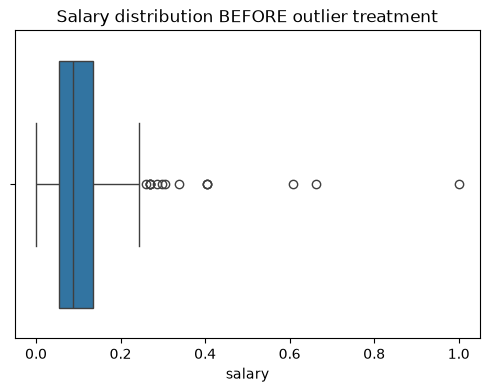

In [20]:
# Visualize the salary distribution before outlier treatment
plt.figure(figsize=(6,4))
sns.boxplot(x=df['salary'])
plt.title('Salary distribution BEFORE outlier treatment')
plt.show()

## Step 6  Option 1: Identifying Outliers Using Z-Scores
The value of 3 in the context of Z-scores is often used as a threshold to identify outliers in a dataset. A Z-score represents how many standard deviations a data point is away from the mean of the dataset. Specifically:

A Z-score of 0 means the data point is exactly at the mean.
A Z-score of 1 means the data point is one standard deviation above the mean, and so on.
A Z-score of 3 corresponds to a data point being 3 standard deviations away from the mean. For a normal distribution, about 99.7% of the data points fall within 3 standard deviations of the mean (according to the 68-95-99.7 rule, which describes the spread of data in a normal distribution). Therefore, points with Z-scores greater than 3 or less than -3 are considered unusually far from the mean and are often flagged as outliers.

This threshold (Z > 3 or Z < -3) is commonly used in many statistical applications because it captures the extreme values that are rare in a normal distribution, which are typically considered to be outliers. However, the choice of threshold can vary depending on the specific application and the nature of the data.



[![Chat-GPT-Image-Aug-20-2026-08-06-05-PM.png](https://i.postimg.cc/2SFTtcXL/Chat-GPT-Image-Aug-20-2026-08-06-05-PM.png)](https://postimg.cc/4Yyz75GX)

In [21]:
columns_to_check = ["salary"]
z_score = stats.zscore(df[columns_to_check])
u = (z_score>3)
l = (z_score<-3)
indx = u | l
clean_df = df[~indx]
df.info()
clean_df.info()


<class 'pandas.DataFrame'>
Index: 148 entries, 0 to 213
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           148 non-null    int64  
 1   gender          148 non-null    str    
 2   hsc_p           148 non-null    float64
 3   hsc_s           148 non-null    str    
 4   degree_p        148 non-null    float64
 5   degree_t        148 non-null    str    
 6   etest_p         148 non-null    float64
 7   specialisation  148 non-null    str    
 8   mba_p           148 non-null    float64
 9   salary          148 non-null    float64
dtypes: float64(5), int64(1), str(4)
memory usage: 12.7 KB
<class 'pandas.DataFrame'>
Index: 145 entries, 0 to 213
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           145 non-null    int64  
 1   gender          145 non-null    str    
 2   hsc_p           145 non-null    float6

### Option 2:  Capping and Flooring Outliers
Capping and flooring is an outlier-treatment technique where extreme values are replaced with predefined boundary values instead of deleting the records.

In [22]:
ll = df["salary"].quantile(0.05)
ul = df["salary"].quantile(0.95)
df_capped = df.copy()
df_capped["salary"]= df_capped["salary"].clip(ll,ul)
df_capped.info()
df.head()

<class 'pandas.DataFrame'>
Index: 148 entries, 0 to 213
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           148 non-null    int64  
 1   gender          148 non-null    str    
 2   hsc_p           148 non-null    float64
 3   hsc_s           148 non-null    str    
 4   degree_p        148 non-null    float64
 5   degree_t        148 non-null    str    
 6   etest_p         148 non-null    float64
 7   specialisation  148 non-null    str    
 8   mba_p           148 non-null    float64
 9   salary          148 non-null    float64
dtypes: float64(5), int64(1), str(4)
memory usage: 12.7 KB


,sl_no,gender,hsc_p,hsc_s,degree_p,degree_t,etest_p,specialisation,mba_p,salary
0,1,M,0.857051,Commerce,0.057143,Sci&Tech,0.104167,Mkt&HR,58.80,0.094595
1,2,M,0.586729,Science,0.613714,Sci&Tech,0.760417,Mkt&Fin,66.28,0.000000
2,3,M,0.409023,Arts,0.228571,Comm&Mgmt,0.520833,Mkt&Fin,57.80,0.067568
4,5,M,0.485812,Commerce,0.494286,Comm&Mgmt,0.975000,Mkt&Fin,55.50,0.304054
7,8,M,0.280990,Science,0.285714,Sci&Tech,0.354167,Mkt&Fin,62.14,0.070270


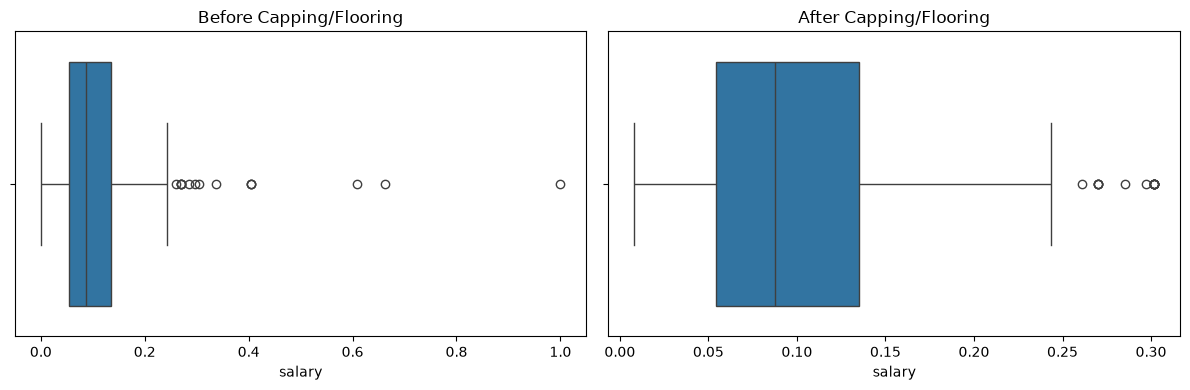

In [23]:
# Visualize the salary distribution after outlier treatment (capping & flooring)
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.boxplot(x=df['salary'])
plt.title('Before Capping/Flooring')

plt.subplot(1,2,2)
sns.boxplot(x=df_capped['salary'])
plt.title('After Capping/Flooring')

plt.tight_layout()
plt.show()

# Adopt the capped values going forward
df['salary'] = df_capped['salary']

## Step 7: Convert categorical variables into numerical format using LabelEncoder ().
[![Picture1.png](https://i.postimg.cc/yNpNvnVd/Picture1.png)](https://postimg.cc/zLW5fCHZ)




In [24]:
# Convert categorical variables into numerical format using LabelEncoder
L1 = LabelEncoder()
df['gender'] = L1.fit_transform(df['gender'])
df['hsc_s'] = L1.fit_transform(df['hsc_s'])
df['degree_t'] = L1.fit_transform(df['degree_t'])
df['specialisation'] = L1.fit_transform(df['specialisation'])
df.head()

,sl_no,gender,hsc_p,hsc_s,degree_p,degree_t,etest_p,specialisation,mba_p,salary
0,1,1,0.857051,1,0.057143,2,0.104167,1,58.80,0.094595
1,2,1,0.586729,2,0.613714,2,0.760417,0,66.28,0.008243
2,3,1,0.409023,0,0.228571,0,0.520833,0,57.80,0.067568
4,5,1,0.485812,1,0.494286,0,0.975000,0,55.50,0.301689
7,8,1,0.280990,2,0.285714,2,0.354167,0,62.14,0.070270


## Convert categorical variables into numerical format using one hot encoder

[![Picture2.png](https://i.postimg.cc/gcZ0Hv1J/Picture2.png)](https://postimg.cc/HjTHp7YD)

In [25]:
L1 = LabelEncoder()
df["gender"]=L1.fit_transform(df["gender"])
df["hsc_s"]=L1.fit_transform(df["hsc_s"])
df["degree_t"]=L1.fit_transform(df["degree_t"])
df["specialisation"]=L1.fit_transform(df["specialisation"])
df.head()



,sl_no,gender,hsc_p,hsc_s,degree_p,degree_t,etest_p,specialisation,mba_p,salary
0,1,1,0.857051,1,0.057143,2,0.104167,1,58.80,0.094595
1,2,1,0.586729,2,0.613714,2,0.760417,0,66.28,0.008243
2,3,1,0.409023,0,0.228571,0,0.520833,0,57.80,0.067568
4,5,1,0.485812,1,0.494286,0,0.975000,0,55.50,0.301689
7,8,1,0.280990,2,0.285714,2,0.354167,0,62.14,0.070270


In [26]:
c=["gender"]
one_hot_encoded_data = pd.get_dummies(df,columns=c)
one_hot_encoded_data.to_csv('clean.csv', index=False)
one_hot_encoded_data.head()
Y = df['salary'].copy()

#Remove target and ID from features

X = df.drop(columns = ['salary', 'sl_no']).copy()

In [27]:
# Final verification of the model-ready dataset
print('Missing values:\n', df.isnull().sum())
print('\nData types:\n', df.dtypes)
print('\nShape:', df.shape)

# Save the final, fully transformed, model-ready dataset
df.to_csv('Final.csv', index=False)
print("\nFinal model-ready dataset saved as 'Final.csv'")

Missing values:
 sl_no             0
gender            0
hsc_p             0
hsc_s             0
degree_p          0
degree_t          0
etest_p           0
specialisation    0
mba_p             0
salary            0
dtype: int64

Data types:
 sl_no               int64
gender              int64
hsc_p             float64
hsc_s               int64
degree_p          float64
degree_t            int64
etest_p           float64
specialisation      int64
mba_p             float64
salary            float64
dtype: object

Shape: (148, 10)

Final model-ready dataset saved as 'Final.csv'


# Exercise: Data Cleaning and Transformation – Automobile Dataset

## Step 1: Load and Explore the Dataset

### 1. Load the Dataset
- Import Pandas and load the Automobile dataset.
- Display the first 10 rows.
- Display the shape of the dataset.

### 2. Explore the Dataset
- Display the column names.
- Display the data types.
- Generate descriptive statistics.
- Identify numerical and categorical columns.
- Display unique values in categorical columns.

## Step 2: Data Cleaning

### 3. Check Missing Values
- Check for missing values in each column.
- Display the number and percentage of missing values.

### 4. Handle Missing Values
- Replace missing numerical values using mean or median.
- Replace missing categorical values using mode.
- Verify that no missing values remain.

### 5. Remove Duplicate Records
- Check for duplicate rows.
- Display the number of duplicate records.
- Remove duplicate records.
- Verify the result.

### 6. Clean the `horsepower` Column
- Identify non-numeric values such as `?`.
- Replace `?` with `NaN`.
- Convert `horsepower` to numeric.
- Handle the resulting missing values.

## Step 3: Data Transformation

### 7. Transform the `origin` Column
- Display the unique values in `origin`.
- Convert the values into meaningful labels:
  - `1` → `usa`
  - `2` → `europe`
  - `3` → `japan`

### 8. Create `weight_kg`
- Create a new column `weight_kg`.
- Convert weight from pounds to kilograms.

  `weight_kg = weight × 0.453592`

### 9. Create `mpg_category`
Create a new column based on `mpg`:
- `< 20` → `Low`
- `20–29` → `Medium`
- `≥ 30` → `High`

### 10. Create `vehicle_age`
- Create a new column `vehicle_age`.
- Assume the current year is 2026.

  `vehicle_age = 2026 - model_year`

### 11. Rename Columns
Rename:
- `mpg` → `miles_per_gallon`
- `horsepower` → `hp`
- `weight` → `weight_lbs`
- `model_year` → `year`

### 12. Filter the Data
Display vehicles:
- With `mpg > 30`
- With `horsepower > 150`
- With `cylinders >= 6`
- Manufactured after 1980
- Originating from `usa`

## Step 4: Encoding Categorical Data

### 13. Label Encoding
- Apply `LabelEncoder` to the `origin` column.
- Create a new column `origin_encoded`.
- Display the original and encoded values.
- Display the category-to-label mapping.

### 14. One-Hot Encoding
- Apply One-Hot Encoding to the `origin` column.
- Compare Label Encoding and One-Hot Encoding.
- Which encoding method is more appropriate for `origin`? Explain why.

## Step 5: Outlier Detection

### 15. Identify Outliers Using Z-Scores
- Calculate the Z-score for the numerical features.
- Identify observations with `|Z-score| > 3` as outliers.
- Count the outliers in each numerical column.
- Display the rows containing outliers.
- Decide whether the outliers should be removed or retained.

## Step 6: Feature Scaling

### 16. Standardization Using StandardScaler
- Select the numerical features.
- Apply `StandardScaler`.
- Display the standardized values.
- Verify that the features have approximately mean `0` and standard deviation `1`.

## Step 7: Normalization

### 17. Normalization Using MinMaxScaler
- Apply `MinMaxScaler` to the numerical features.
- Transform the features to the range `[0, 1]`.
- Display the normalized values.
- Compare **Standardization** and **Normalization**.
- Explain when each scaling method is appropriate.

## Step 8: Create Features and Target

### 18. Create X and Y Variables
- Select the appropriate input features as **X (independent variables)**.
- Select `mpg` as **Y (target variable)**.
- Display the shape of `X` and `Y`.
- Save `X` and `Y` into `automobile_X_Y.csv`.
- Load the CSV file again and display the first 5 rows.

## Step 9: Save the Final Dataset

### 19. Save the Preprocessed Dataset
- Combine the processed features and target variable.
- Display the final dataset.
- Check for missing values.
- Save the final dataset as `automobile_preprocessed.csv`.

### 1. Load the Dataset & 2. Explore the Dataset

In [28]:
# Load the local Automobile dataset
auto_df = pd.read_csv("Automobile.csv")

print("First 10 rows:")
display(auto_df.head(10))
print("\nShape of the dataset (rows, columns):", auto_df.shape)

First 10 rows:


,name,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,chevrolet chevelle malibu,18.0,8.0,307.0,130.0,3504.0,12.0,70,usa
1,buick skylark 320,15.0,8.0,350.0,165.0,3693.0,11.5,70,usa
2,plymouth satellite,18.0,8.0,318.0,150.0,3436.0,11.0,70,usa
3,amc rebel sst,16.0,8.0,304.0,150.0,3433.0,12.0,70,usa
4,ford torino,17.0,NaN,302.0,140.0,3449.0,10.5,70,usa
5,ford galaxie 500,15.0,8.0,429.0,198.0,4341.0,10.0,70,usa
6,chevrolet impala,14.0,8.0,454.0,220.0,NaN,9.0,70,usa
7,plymouth fury iii,14.0,8.0,440.0,215.0,4312.0,8.5,70,usa
8,pontiac catalina,14.0,8.0,455.0,NaN,4425.0,10.0,70,usa
9,amc ambassador dpl,15.0,8.0,390.0,190.0,3850.0,8.5,70,usa



Shape of the dataset (rows, columns): (398, 9)


In [29]:
print("Column names:\n", auto_df.columns.tolist())

print("\nData types:\n")
print(auto_df.dtypes)

print("\nDescriptive statistics:\n")
display(auto_df.describe(include='all'))

numerical_cols = auto_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = auto_df.select_dtypes(exclude=[np.number]).columns.tolist()
print("\nNumerical columns:", numerical_cols)
print("Categorical / object columns:", categorical_cols)

print("\nUnique values in 'origin':", sorted(auto_df['origin'].dropna().unique()))
print("Unique values in 'cylinders':", sorted(auto_df['cylinders'].dropna().unique()))

Column names:
 ['name', 'mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin']

Data types:

name                str
mpg             float64
cylinders       float64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
model_year        int64
origin              str
dtype: object

Descriptive statistics:



,name,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398,398.000000,395.000000,395.000000,386.000000,396.000000,395.000000,398.000000,398
unique,305,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,ford pinto,NaN,NaN,NaN,NaN,NaN,NaN,NaN,usa
freq,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,249
mean,NaN,23.514573,5.445570,193.340506,104.316062,2965.025253,15.562278,76.010050,NaN
std,NaN,7.815984,1.696203,104.425993,38.086281,845.254458,2.750260,3.697627,NaN
min,NaN,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,NaN
25%,NaN,17.500000,4.000000,102.500000,75.250000,2222.250000,13.850000,73.000000,NaN
50%,NaN,23.000000,4.000000,146.000000,92.500000,2797.500000,15.500000,76.000000,NaN
75%,NaN,29.000000,8.000000,262.000000,125.000000,3581.750000,17.150000,79.000000,NaN



Numerical columns: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
Categorical / object columns: ['name', 'origin']

Unique values in 'origin': ['europe', 'japan', 'usa']
Unique values in 'cylinders': [np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(8.0)]


## Step 2: Data Cleaning
### 3. Check Missing Values

In [30]:
print("Missing values per column:\n")
print(auto_df.isnull().sum())

print("\nPercentage of missing values per column:\n")
print((auto_df.isnull().sum() / len(auto_df)) * 100)

Missing values per column:

name             0
mpg              0
cylinders        3
displacement     3
horsepower      12
weight           2
acceleration     3
model_year       0
origin           0
dtype: int64

Percentage of missing values per column:

name            0.000000
mpg             0.000000
cylinders       0.753769
displacement    0.753769
horsepower      3.015075
weight          0.502513
acceleration    0.753769
model_year      0.000000
origin          0.000000
dtype: float64


### 4. Handle Missing Values

In [31]:
# Replace missing numerical values with the median
# (horsepower is handled separately in Step 6, so it is skipped here)
for col in auto_df.select_dtypes(include=[np.number]).columns:
    if col == 'horsepower':
        continue
    if auto_df[col].isnull().sum() > 0:
        auto_df[col] = auto_df[col].fillna(auto_df[col].median())

# Replace missing categorical values with the mode
for col in auto_df.select_dtypes(exclude=[np.number]).columns:
    if auto_df[col].isnull().sum() > 0:
        auto_df[col] = auto_df[col].fillna(auto_df[col].mode()[0])

print("Missing values after handling (horsepower still pending):\n")
print(auto_df.isnull().sum())

Missing values after handling (horsepower still pending):

name             0
mpg              0
cylinders        0
displacement     0
horsepower      12
weight           0
acceleration     0
model_year       0
origin           0
dtype: int64


### 5. Remove Duplicate Records

In [32]:
print("Number of duplicate rows:", auto_df.duplicated().sum())

auto_df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", auto_df.shape)
print("Duplicate rows remaining:", auto_df.duplicated().sum())

Number of duplicate rows: 0
Shape after removing duplicates: (398, 9)
Duplicate rows remaining: 0


### 6. Clean the `horsepower` Column

In [33]:
print("Data type of horsepower:", auto_df['horsepower'].dtype)

# Some versions of this dataset store missing horsepower as the string '?'
# instead of a real NaN - handle both possibilities robustly
auto_df['horsepower'] = auto_df['horsepower'].replace('?', np.nan)
auto_df['horsepower'] = pd.to_numeric(auto_df['horsepower'], errors='coerce')

print("Missing horsepower values found:", auto_df['horsepower'].isnull().sum())

# Handle the resulting missing values using the median
auto_df['horsepower'] = auto_df['horsepower'].fillna(auto_df['horsepower'].median())
print("Missing horsepower values after imputation:", auto_df['horsepower'].isnull().sum())

Data type of horsepower: float64
Missing horsepower values found: 12
Missing horsepower values after imputation: 0


## Step 3: Data Transformation
### 7. Transform the `origin` Column

In [34]:
print("Unique values in 'origin':", auto_df['origin'].unique())

# In this file 'origin' is already stored as descriptive labels (usa/europe/japan).
# If it were numerically coded (1/2/3), we would map it like this:
if pd.api.types.is_numeric_dtype(auto_df['origin']):
    origin_map = {1: 'usa', 2: 'europe', 3: 'japan'}
    auto_df['origin'] = auto_df['origin'].map(origin_map)
    print("Numeric origin codes were mapped to labels.")
else:
    print("'origin' is already stored as descriptive labels - no mapping needed.")

print("\nValue counts:\n", auto_df['origin'].value_counts())

Unique values in 'origin': <StringArray>
['usa', 'japan', 'europe']
Length: 3, dtype: str
'origin' is already stored as descriptive labels - no mapping needed.

Value counts:
 origin
usa       249
japan      79
europe     70
Name: count, dtype: int64


### 8. Create `weight_kg`

In [35]:
auto_df['weight_kg'] = auto_df['weight'] * 0.453592
auto_df[['weight', 'weight_kg']].head()

,weight,weight_kg
0,3504.0,1589.386368
1,3693.0,1675.115256
2,3436.0,1558.542112
3,3433.0,1557.181336
4,3449.0,1564.438808


### 9. Create `mpg_category`

In [36]:
def categorize_mpg(mpg):
    if mpg < 20:
        return 'Low'
    elif mpg < 30:
        return 'Medium'
    else:
        return 'High'

auto_df['mpg_category'] = auto_df['mpg'].apply(categorize_mpg)
auto_df[['mpg', 'mpg_category']].head()

,mpg,mpg_category
0,18.0,Low
1,15.0,Low
2,18.0,Low
3,16.0,Low
4,17.0,Low


### 10. Create `vehicle_age`

In [37]:
print("model_year range:", auto_df['model_year'].min(), "-", auto_df['model_year'].max())

# The raw model_year values are 2-digit (70-82), representing 1970-1982
auto_df['model_year'] = auto_df['model_year'] + 1900

# Assume the current year is 2026
auto_df['vehicle_age'] = 2026 - auto_df['model_year']
auto_df[['model_year', 'vehicle_age']].head()

model_year range: 70 - 82


,model_year,vehicle_age
0,1970,56
1,1970,56
2,1970,56
3,1970,56
4,1970,56


### 11. Rename Columns

In [39]:
auto_df.rename(columns={
    'mpg': 'miles_per_gallon',
    'horsepower': 'hp',
    'weight': 'weight_lbs',
    'model_year': 'year'
}, inplace=True)

auto_df.head()

,name,miles_per_gallon,cylinders,displacement,hp,weight_lbs,acceleration,year,origin,weight_kg,mpg_category,vehicle_age
0,chevrolet chevelle malibu,18.0,8.0,307.0,130.0,3504.0,12.0,1970,usa,1589.386368,Low,56
1,buick skylark 320,15.0,8.0,350.0,165.0,3693.0,11.5,1970,usa,1675.115256,Low,56
2,plymouth satellite,18.0,8.0,318.0,150.0,3436.0,11.0,1970,usa,1558.542112,Low,56
3,amc rebel sst,16.0,8.0,304.0,150.0,3433.0,12.0,1970,usa,1557.181336,Low,56
4,ford torino,17.0,4.0,302.0,140.0,3449.0,10.5,1970,usa,1564.438808,Low,56


### 12. Filter the Data

In [40]:
print("Vehicles with mpg > 30:")
display(auto_df[auto_df['miles_per_gallon'] > 30])

print("\nVehicles with horsepower > 150:")
display(auto_df[auto_df['hp'] > 150])

print("\nVehicles with cylinders >= 6:")
display(auto_df[auto_df['cylinders'] >= 6])

print("\nVehicles manufactured after 1980:")
display(auto_df[auto_df['year'] > 1980])

print("\nVehicles originating from usa:")
display(auto_df[auto_df['origin'] == 'usa'])

Vehicles with mpg > 30:


,name,miles_per_gallon,cylinders,displacement,hp,weight_lbs,acceleration,year,origin,weight_kg,mpg_category,vehicle_age
53,toyota corolla 1200,31.0,4.0,71.0,65.0,1773.0,19.0,1971,japan,804.218616,High,55
54,datsun 1200,35.0,4.0,72.0,69.0,1613.0,18.0,1971,japan,731.643896,High,55
129,datsun b210,31.0,4.0,79.0,67.0,1950.0,19.0,1974,japan,884.504400,High,52
131,toyota corolla 1200,32.0,4.0,71.0,92.5,1836.0,15.5,1974,japan,832.794912,High,52
144,toyota corona,31.0,4.0,76.0,52.0,1649.0,16.5,1974,japan,747.973208,High,52
...,...,...,...,...,...,...,...,...,...,...,...,...
390,toyota celica gt,32.0,4.0,144.0,96.0,2665.0,13.9,1982,japan,1208.822680,High,44
391,dodge charger 2.2,36.0,4.0,135.0,84.0,2370.0,13.0,1982,usa,1075.013040,High,44
394,vw pickup,44.0,4.0,97.0,52.0,2130.0,24.6,1982,europe,966.150960,High,44
395,dodge rampage,32.0,4.0,135.0,84.0,2295.0,11.6,1982,usa,1040.993640,High,44



Vehicles with horsepower > 150:


,name,miles_per_gallon,cylinders,displacement,hp,weight_lbs,acceleration,year,origin,weight_kg,mpg_category,vehicle_age
1,buick skylark 320,15.0,8.0,350.0,165.0,3693.0,11.5,1970,usa,1675.115256,Low,56
5,ford galaxie 500,15.0,8.0,429.0,198.0,4341.0,10.0,1970,usa,1969.042872,Low,56
6,chevrolet impala,14.0,8.0,454.0,220.0,2797.5,9.0,1970,usa,1268.923620,Low,56
7,plymouth fury iii,14.0,8.0,440.0,215.0,4312.0,8.5,1970,usa,1955.888704,Low,56
9,amc ambassador dpl,15.0,8.0,390.0,190.0,3850.0,8.5,1970,usa,1746.329200,Low,56
10,dodge challenger se,15.0,8.0,383.0,170.0,3563.0,10.0,1970,usa,1616.148296,Low,56
11,plymouth 'cuda 340,14.0,8.0,340.0,160.0,3609.0,8.0,1970,usa,1637.013528,Low,56
13,buick estate wagon (sw),14.0,8.0,455.0,225.0,3086.0,10.0,1970,usa,1399.784912,Low,56
25,ford f250,10.0,8.0,360.0,215.0,4615.0,14.0,1970,usa,2093.327080,Low,56
26,chevy c20,10.0,8.0,307.0,200.0,4376.0,15.0,1970,usa,1984.918592,Low,56



Vehicles with cylinders >= 6:


,name,miles_per_gallon,cylinders,displacement,hp,weight_lbs,acceleration,year,origin,weight_kg,mpg_category,vehicle_age
0,chevrolet chevelle malibu,18.0,8.0,307.0,130.0,3504.0,12.0,1970,usa,1589.386368,Low,56
1,buick skylark 320,15.0,8.0,350.0,165.0,3693.0,11.5,1970,usa,1675.115256,Low,56
2,plymouth satellite,18.0,8.0,318.0,150.0,3436.0,11.0,1970,usa,1558.542112,Low,56
3,amc rebel sst,16.0,8.0,304.0,150.0,3433.0,12.0,1970,usa,1557.181336,Low,56
5,ford galaxie 500,15.0,8.0,429.0,198.0,4341.0,10.0,1970,usa,1969.042872,Low,56
...,...,...,...,...,...,...,...,...,...,...,...,...
365,ford granada gl,20.2,6.0,200.0,88.0,3060.0,17.1,1981,usa,1387.991520,Medium,45
366,chrysler lebaron salon,17.6,6.0,225.0,85.0,3465.0,16.6,1981,usa,1571.696280,Low,45
386,buick century limited,25.0,6.0,181.0,110.0,2945.0,16.4,1982,usa,1335.828440,Medium,44
387,oldsmobile cutlass ciera (diesel),38.0,6.0,262.0,85.0,3015.0,17.0,1982,usa,1367.579880,High,44



Vehicles manufactured after 1980:


,name,miles_per_gallon,cylinders,displacement,hp,weight_lbs,acceleration,year,origin,weight_kg,mpg_category,vehicle_age
338,plymouth reliant,27.2,4.0,135.0,84.0,2490.0,15.7,1981,usa,1129.44408,Medium,45
339,buick skylark,26.6,4.0,151.0,84.0,2635.0,16.4,1981,usa,1195.21492,Medium,45
340,dodge aries wagon (sw),25.8,4.0,156.0,92.0,2620.0,14.4,1981,usa,1188.41104,Medium,45
341,chevrolet citation,23.5,6.0,173.0,110.0,2725.0,12.6,1981,usa,1236.03820,Medium,45
342,plymouth reliant,30.0,4.0,135.0,84.0,2385.0,12.9,1981,usa,1081.81692,High,45
343,toyota starlet,39.1,4.0,79.0,58.0,1755.0,16.9,1981,japan,796.05396,High,45
344,plymouth champ,39.0,4.0,86.0,64.0,1875.0,16.4,1981,usa,850.48500,High,45
345,honda civic 1300,35.1,4.0,81.0,60.0,1760.0,16.1,1981,japan,798.32192,High,45
346,subaru,32.3,4.0,97.0,67.0,2065.0,17.8,1981,japan,936.66748,High,45
347,datsun 210 mpg,37.0,4.0,85.0,65.0,1975.0,19.4,1981,japan,895.84420,High,45



Vehicles originating from usa:


,name,miles_per_gallon,cylinders,displacement,hp,weight_lbs,acceleration,year,origin,weight_kg,mpg_category,vehicle_age
0,chevrolet chevelle malibu,18.0,8.0,307.0,130.0,3504.0,12.0,1970,usa,1589.386368,Low,56
1,buick skylark 320,15.0,8.0,350.0,165.0,3693.0,11.5,1970,usa,1675.115256,Low,56
2,plymouth satellite,18.0,8.0,318.0,150.0,3436.0,11.0,1970,usa,1558.542112,Low,56
3,amc rebel sst,16.0,8.0,304.0,150.0,3433.0,12.0,1970,usa,1557.181336,Low,56
4,ford torino,17.0,4.0,302.0,140.0,3449.0,10.5,1970,usa,1564.438808,Low,56
...,...,...,...,...,...,...,...,...,...,...,...,...
392,chevrolet camaro,27.0,4.0,151.0,90.0,2950.0,17.3,1982,usa,1338.096400,Medium,44
393,ford mustang gl,27.0,4.0,140.0,86.0,2790.0,15.6,1982,usa,1265.521680,Medium,44
395,dodge rampage,32.0,4.0,135.0,84.0,2295.0,11.6,1982,usa,1040.993640,High,44
396,ford ranger,28.0,4.0,120.0,79.0,2625.0,18.6,1982,usa,1190.679000,Medium,44


## Step 4: Encoding Categorical Data
### 13. Label Encoding

In [41]:
le = LabelEncoder()
auto_df['origin_encoded'] = le.fit_transform(auto_df['origin'])

print("Original vs encoded values:")
display(auto_df[['origin', 'origin_encoded']].drop_duplicates().reset_index(drop=True))

mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("\nCategory-to-label mapping:", mapping)

Original vs encoded values:


,origin,origin_encoded
0,usa,2
1,japan,1
2,europe,0



Category-to-label mapping: {'europe': np.int64(0), 'japan': np.int64(1), 'usa': np.int64(2)}


### 14. One-Hot Encoding

In [42]:
one_hot_origin = pd.get_dummies(auto_df['origin'], prefix='origin')
display(one_hot_origin.head())

auto_df = pd.concat([auto_df, one_hot_origin], axis=1)
auto_df.head()

,origin_europe,origin_japan,origin_usa
0,False,False,True
1,False,False,True
2,False,False,True
3,False,False,True
4,False,False,True


,name,miles_per_gallon,cylinders,displacement,hp,weight_lbs,acceleration,year,origin,weight_kg,mpg_category,vehicle_age,origin_encoded,origin_europe,origin_japan,origin_usa
0,chevrolet chevelle malibu,18.0,8.0,307.0,130.0,3504.0,12.0,1970,usa,1589.386368,Low,56,2,False,False,True
1,buick skylark 320,15.0,8.0,350.0,165.0,3693.0,11.5,1970,usa,1675.115256,Low,56,2,False,False,True
2,plymouth satellite,18.0,8.0,318.0,150.0,3436.0,11.0,1970,usa,1558.542112,Low,56,2,False,False,True
3,amc rebel sst,16.0,8.0,304.0,150.0,3433.0,12.0,1970,usa,1557.181336,Low,56,2,False,False,True
4,ford torino,17.0,4.0,302.0,140.0,3449.0,10.5,1970,usa,1564.438808,Low,56,2,False,False,True


**Label Encoding vs One-Hot Encoding:** Label Encoding assigns a single integer (0, 1, 2, ...) to each category, which implicitly introduces an ordinal relationship between the categories (e.g. `japan` > `europe` > `usa`) that does not actually exist for `origin`. One-Hot Encoding instead creates a separate binary column for each category, so no false ordering is imposed.

**Which is more appropriate for `origin`?** One-Hot Encoding is the better choice here because `origin` is a *nominal* (unordered) categorical variable — there is no natural ranking between USA, Europe, and Japan. Label Encoding would be more appropriate for *ordinal* variables where the categories have a genuine order (e.g. low/medium/high).

## Step 5: Outlier Detection
### 15. Identify Outliers Using Z-Scores

In [43]:
numerical_features = ['miles_per_gallon', 'cylinders', 'displacement', 'hp',
                      'weight_lbs', 'acceleration', 'year']

z_scores = auto_df[numerical_features].apply(zscore)
outlier_mask = z_scores.abs() > 3

print("Outlier count per column:\n")
print(outlier_mask.sum())

outlier_rows = auto_df[outlier_mask.any(axis=1)]
print("\nRows containing outliers:")
display(outlier_rows)

Outlier count per column:

miles_per_gallon    0
cylinders           0
displacement        0
hp                  4
weight_lbs          0
acceleration        2
year                0
dtype: int64

Rows containing outliers:


,name,miles_per_gallon,cylinders,displacement,hp,weight_lbs,acceleration,year,origin,weight_kg,mpg_category,vehicle_age,origin_encoded,origin_europe,origin_japan,origin_usa
6,chevrolet impala,14.0,8.0,454.0,220.0,2797.5,9.0,1970,usa,1268.923620,Low,56,2,False,False,True
13,buick estate wagon (sw),14.0,8.0,455.0,225.0,3086.0,10.0,1970,usa,1399.784912,Low,56,2,False,False,True
95,buick electra 225 custom,12.0,8.0,455.0,225.0,4951.0,11.0,1973,usa,2245.733992,Low,53,2,False,False,True
116,pontiac grand prix,16.0,8.0,400.0,230.0,4278.0,9.5,1973,usa,1940.466576,Low,53,2,False,False,True
299,peugeot 504,27.2,4.0,141.0,71.0,3190.0,24.8,1979,europe,1446.958480,Medium,47,0,True,False,False
394,vw pickup,44.0,4.0,97.0,52.0,2130.0,24.6,1982,europe,966.150960,High,44,0,True,False,False


**Remove or retain?** These outliers (e.g. very high horsepower/displacement muscle cars) are genuine, valid vehicles rather than data-entry errors, so they carry real information about the range of the automobile market. It is generally better to **retain** them and instead use scaling/robust models, only removing outliers if they are confirmed to be measurement or entry errors.

## Step 6: Feature Scaling
### 16. Standardization Using StandardScaler

In [44]:
scaler = StandardScaler()
scaled_values = scaler.fit_transform(auto_df[numerical_features])
scaled_df = pd.DataFrame(scaled_values,
                          columns=[f"{c}_scaled" for c in numerical_features],
                          index=auto_df.index)

display(scaled_df.head())

print("\nMean after scaling (should be ~0):\n", scaled_df.mean())
print("\nStd after scaling (should be ~1):\n", scaled_df.std())

,miles_per_gallon_scaled,cylinders_scaled,displacement_scaled,hp_scaled,weight_lbs_scaled,acceleration_scaled,year_scaled
0,-0.706439,1.515897,1.096516,0.694154,0.641001,-1.301636,-1.627426
1,-1.090751,1.515897,1.510055,1.627150,0.865428,-1.484357,-1.627426
2,-0.706439,1.515897,1.202305,1.227295,0.560255,-1.667078,-1.627426
3,-0.962647,1.515897,1.067664,1.227295,0.556693,-1.301636,-1.627426
4,-0.834543,-0.847774,1.048430,0.960725,0.575692,-1.849799,-1.627426



Mean after scaling (should be ~0):
 miles_per_gallon_scaled    7.141133e-17
cylinders_scaled          -1.963812e-16
displacement_scaled       -8.926416e-17
hp_scaled                  3.570567e-17
weight_lbs_scaled         -1.249698e-16
acceleration_scaled       -6.427020e-16
year_scaled                2.520820e-14
dtype: float64

Std after scaling (should be ~1):
 miles_per_gallon_scaled    1.001259
cylinders_scaled           1.001259
displacement_scaled        1.001259
hp_scaled                  1.001259
weight_lbs_scaled          1.001259
acceleration_scaled        1.001259
year_scaled                1.001259
dtype: float64


## Step 7: Normalization
### 17. Normalization Using MinMaxScaler

In [45]:
minmax = MinMaxScaler()
normalized_values = minmax.fit_transform(auto_df[numerical_features])
normalized_df = pd.DataFrame(normalized_values,
                              columns=[f"{c}_norm" for c in numerical_features],
                              index=auto_df.index)

display(normalized_df.head())

,miles_per_gallon_norm,cylinders_norm,displacement_norm,hp_norm,weight_lbs_norm,acceleration_norm,year_norm
0,0.239362,1.0,0.617571,0.456522,0.536150,0.238095,0.0
1,0.159574,1.0,0.728682,0.646739,0.589736,0.208333,0.0
2,0.239362,1.0,0.645995,0.565217,0.516870,0.178571,0.0
3,0.186170,1.0,0.609819,0.565217,0.516019,0.238095,0.0
4,0.212766,0.2,0.604651,0.510870,0.520556,0.148810,0.0


**Standardization vs Normalization:** Standardization (`StandardScaler`) rescales data to have a mean of 0 and a standard deviation of 1, and does not bound the values to a fixed range — it is preferred when the data roughly follows a normal distribution or when the model assumes standardized input (e.g. linear/logistic regression, PCA, SVM). Normalization (`MinMaxScaler`) rescales data to a fixed `[0, 1]` range and is preferred when the algorithm is sensitive to the absolute scale of inputs but not their distribution (e.g. neural networks, k-NN, image-pixel data), or when the data does not follow a normal distribution.

## Step 8: Create Features and Target
### 18. Create X and Y Variables

In [46]:
# 'name' (free-text car name), 'mpg_category' (derived from the target itself,
# i.e. leakage) and 'origin' (string, now represented by origin_encoded/one-hot
# columns) are dropped from the feature set
X = auto_df.drop(columns=['miles_per_gallon', 'name', 'origin', 'mpg_category']).copy()
Y = auto_df['miles_per_gallon'].copy()

print("Shape of X:", X.shape)
print("Shape of Y:", Y.shape)

xy_df = pd.concat([X, Y], axis=1)
xy_df.to_csv('automobile_X_Y.csv', index=False)

reloaded = pd.read_csv('automobile_X_Y.csv')
display(reloaded.head())

Shape of X: (398, 12)
Shape of Y: (398,)


,cylinders,displacement,hp,weight_lbs,acceleration,year,weight_kg,vehicle_age,origin_encoded,origin_europe,origin_japan,origin_usa,miles_per_gallon
0,8.0,307.0,130.0,3504.0,12.0,1970,1589.386368,56,2,False,False,True,18.0
1,8.0,350.0,165.0,3693.0,11.5,1970,1675.115256,56,2,False,False,True,15.0
2,8.0,318.0,150.0,3436.0,11.0,1970,1558.542112,56,2,False,False,True,18.0
3,8.0,304.0,150.0,3433.0,12.0,1970,1557.181336,56,2,False,False,True,16.0
4,4.0,302.0,140.0,3449.0,10.5,1970,1564.438808,56,2,False,False,True,17.0


## Step 9: Save the Final Dataset
### 19. Save the Preprocessed Dataset

In [47]:
final_df = pd.concat([X, Y], axis=1)
display(final_df.head())

print("\nTotal missing values in the final dataset:", final_df.isnull().sum().sum())

final_df.to_csv('automobile_preprocessed.csv', index=False)
print("\nFinal preprocessed dataset saved as 'automobile_preprocessed.csv'")

,cylinders,displacement,hp,weight_lbs,acceleration,year,weight_kg,vehicle_age,origin_encoded,origin_europe,origin_japan,origin_usa,miles_per_gallon
0,8.0,307.0,130.0,3504.0,12.0,1970,1589.386368,56,2,False,False,True,18.0
1,8.0,350.0,165.0,3693.0,11.5,1970,1675.115256,56,2,False,False,True,15.0
2,8.0,318.0,150.0,3436.0,11.0,1970,1558.542112,56,2,False,False,True,18.0
3,8.0,304.0,150.0,3433.0,12.0,1970,1557.181336,56,2,False,False,True,16.0
4,4.0,302.0,140.0,3449.0,10.5,1970,1564.438808,56,2,False,False,True,17.0



Total missing values in the final dataset: 0

Final preprocessed dataset saved as 'automobile_preprocessed.csv'


In [ ]:
, 